In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
DATA_DIR = Path("../outputs/candidate_features")
OUTPUT_DIR = Path("../outputs/ridge_candidate_features")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEEPSEEK_FILE = DATA_DIR / "candidate_features_deepseek.csv"
GEMMA_FILE = DATA_DIR / "candidate_features_gemma.csv"

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Data directory: C:\Users\franc\OneDrive\Geop-Model\outputs\candidate_features
Output directory: C:\Users\franc\OneDrive\Geop-Model\outputs\ridge_candidate_features


In [3]:
deepseek = pd.read_csv(
    DEEPSEEK_FILE,
    parse_dates=["observation_date"]
)

gemma = pd.read_csv(
    GEMMA_FILE,
    parse_dates=["observation_date"]
)

print("DeepSeek:", deepseek.shape)
print("Gemma:", gemma.shape)

DeepSeek: (982, 126)
Gemma: (982, 126)


In [4]:
TARGET = "DEXUSEU_logreturn"

print("DeepSeek shape:", deepseek.shape)
print("Gemma shape:", gemma.shape)

print(
    "\nIdentical dates:",
    deepseek["observation_date"].equals(
        gemma["observation_date"]
    )
)

print(
    "Identical current returns:",
    np.allclose(
        deepseek[TARGET],
        gemma[TARGET]
    )
)

print(
    "\nDeepSeek missing values:",
    deepseek.isna().sum().sum()
)

print(
    "Gemma missing values:",
    gemma.isna().sum().sum()
)

print(
    "\nDate range:",
    deepseek["observation_date"].min(),
    "to",
    deepseek["observation_date"].max()
)

DeepSeek shape: (982, 126)
Gemma shape: (982, 126)

Identical dates: True
Identical current returns: True

DeepSeek missing values: 0
Gemma missing values: 0

Date range: 2017-01-17 00:00:00 to 2021-01-08 00:00:00


In [5]:
# Create next-period EUR/USD return target

deepseek["target_next_return"] = (
    deepseek[TARGET].shift(-1)
)

gemma["target_next_return"] = (
    gemma[TARGET].shift(-1)
)

# Drop final row because t+1 return is unavailable
deepseek_model = (
    deepseek
    .dropna(subset=["target_next_return"])
    .copy()
    .reset_index(drop=True)
)

gemma_model = (
    gemma
    .dropna(subset=["target_next_return"])
    .copy()
    .reset_index(drop=True)
)

# Same 124 candidate predictors as LASSO
FEATURE_COLS = [
    col
    for col in deepseek_model.columns
    if col not in [
        "observation_date",
        TARGET,
        "target_next_return"
    ]
]

X_deepseek = deepseek_model[FEATURE_COLS].copy()
X_gemma = gemma_model[FEATURE_COLS].copy()

y = deepseek_model["target_next_return"].copy()
dates = deepseek_model["observation_date"].copy()

print("Observations:", len(y))
print("Number of predictors:", len(FEATURE_COLS))

print("DeepSeek X:", X_deepseek.shape)
print("Gemma X:", X_gemma.shape)

print(
    "Targets identical:",
    np.allclose(
        deepseek_model["target_next_return"],
        gemma_model["target_next_return"]
    )
)

Observations: 981
Number of predictors: 124
DeepSeek X: (981, 124)
Gemma X: (981, 124)
Targets identical: True


C:\Users\franc\AppData\Local\Temp\ipykernel_12580\2710555207.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  deepseek["target_next_return"] = (
C:\Users\franc\AppData\Local\Temp\ipykernel_12580\2710555207.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gemma["target_next_return"] = (


In [6]:
# Chronological 60/20/20 split

n = len(y)

train_end = int(0.60 * n)
val_end = int(0.80 * n)

# DeepSeek
X_train_deepseek = X_deepseek.iloc[:train_end].copy()
X_val_deepseek = X_deepseek.iloc[train_end:val_end].copy()
X_test_deepseek = X_deepseek.iloc[val_end:].copy()

# Gemma
X_train_gemma = X_gemma.iloc[:train_end].copy()
X_val_gemma = X_gemma.iloc[train_end:val_end].copy()
X_test_gemma = X_gemma.iloc[val_end:].copy()

# Same target for both
y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

dates_train = dates.iloc[:train_end].copy()
dates_val = dates.iloc[train_end:val_end].copy()
dates_test = dates.iloc[val_end:].copy()

print("Training observations:", len(y_train))
print("Validation observations:", len(y_val))
print("Test observations:", len(y_test))

print(
    "\nTraining period:",
    dates_train.iloc[0],
    "to",
    dates_train.iloc[-1]
)

print(
    "Validation period:",
    dates_val.iloc[0],
    "to",
    dates_val.iloc[-1]
)

print(
    "Test period:",
    dates_test.iloc[0],
    "to",
    dates_test.iloc[-1]
)

Training observations: 588
Validation observations: 196
Test observations: 197

Training period: 2017-01-17 00:00:00 to 2019-06-07 00:00:00
Validation period: 2019-06-10 00:00:00 to 2020-03-20 00:00:00
Test period: 2020-03-23 00:00:00 to 2021-01-06 00:00:00


In [7]:
# Standardise using training sample only

scaler_deepseek = StandardScaler()
scaler_gemma = StandardScaler()

X_train_deepseek_scaled = scaler_deepseek.fit_transform(
    X_train_deepseek
)

X_val_deepseek_scaled = scaler_deepseek.transform(
    X_val_deepseek
)

X_test_deepseek_scaled = scaler_deepseek.transform(
    X_test_deepseek
)


X_train_gemma_scaled = scaler_gemma.fit_transform(
    X_train_gemma
)

X_val_gemma_scaled = scaler_gemma.transform(
    X_val_gemma
)

X_test_gemma_scaled = scaler_gemma.transform(
    X_test_gemma
)

print("DeepSeek")
print("Train:", X_train_deepseek_scaled.shape)
print("Validation:", X_val_deepseek_scaled.shape)
print("Test:", X_test_deepseek_scaled.shape)

print("\nGemma")
print("Train:", X_train_gemma_scaled.shape)
print("Validation:", X_val_gemma_scaled.shape)
print("Test:", X_test_gemma_scaled.shape)

DeepSeek
Train: (588, 124)
Validation: (196, 124)
Test: (197, 124)

Gemma
Train: (588, 124)
Validation: (196, 124)
Test: (197, 124)


In [8]:
# Scaling sanity check

print("DeepSeek training mean (max abs):")
print(
    np.abs(
        X_train_deepseek_scaled.mean(axis=0)
    ).max()
)

print("DeepSeek average training std:")
print(
    X_train_deepseek_scaled.std(axis=0).mean()
)

print("\nGemma training mean (max abs):")
print(
    np.abs(
        X_train_gemma_scaled.mean(axis=0)
    ).max()
)

print("Gemma average training std:")
print(
    X_train_gemma_scaled.std(axis=0).mean()
)

DeepSeek training mean (max abs):
8.700523295021635e-16
DeepSeek average training std:
1.0

Gemma training mean (max abs):
8.700523295021635e-16
Gemma average training std:
1.0


In [14]:
# Ridge penalty grid

alphas = np.logspace(-4, 6, 150)

print("Number of alpha values:", len(alphas))
print("Minimum alpha:", alphas.min())
print("Maximum alpha:", alphas.max())

Number of alpha values: 150
Minimum alpha: 0.0001
Maximum alpha: 1000000.0


In [15]:
# Tune Ridge alpha using validation MSE

ridge_val_mse_deepseek = []
ridge_val_mse_gemma = []

for alpha in alphas:

    # DeepSeek
    ridge_ds = Ridge(alpha=alpha)
    ridge_ds.fit(
        X_train_deepseek_scaled,
        y_train
    )

    pred_ds = ridge_ds.predict(
        X_val_deepseek_scaled
    )

    ridge_val_mse_deepseek.append(
        mean_squared_error(y_val, pred_ds)
    )

    # Gemma
    ridge_g = Ridge(alpha=alpha)
    ridge_g.fit(
        X_train_gemma_scaled,
        y_train
    )

    pred_g = ridge_g.predict(
        X_val_gemma_scaled
    )

    ridge_val_mse_gemma.append(
        mean_squared_error(y_val, pred_g)
    )


ridge_val_mse_deepseek = np.array(
    ridge_val_mse_deepseek
)

ridge_val_mse_gemma = np.array(
    ridge_val_mse_gemma
)

best_idx_deepseek = np.argmin(
    ridge_val_mse_deepseek
)

best_idx_gemma = np.argmin(
    ridge_val_mse_gemma
)

best_alpha_deepseek = alphas[
    best_idx_deepseek
]

best_alpha_gemma = alphas[
    best_idx_gemma
]

print("DeepSeek best alpha:", best_alpha_deepseek)
print(
    "DeepSeek validation MSE:",
    ridge_val_mse_deepseek[
        best_idx_deepseek
    ]
)

print("\nGemma best alpha:", best_alpha_gemma)
print(
    "Gemma validation MSE:",
    ridge_val_mse_gemma[
        best_idx_gemma
    ]
)

DeepSeek best alpha: 6098.666701068888
DeepSeek validation MSE: 1.5061321339720085e-05

Gemma best alpha: 17990.09915577833
Gemma validation MSE: 1.5167137080516047e-05


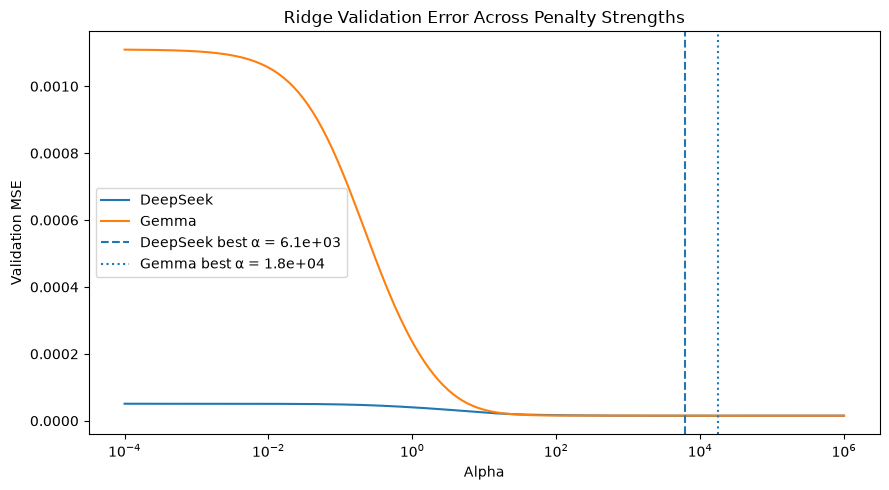

In [16]:
# Ridge validation curves

plt.figure(figsize=(9, 5))

plt.semilogx(
    alphas,
    ridge_val_mse_deepseek,
    label="DeepSeek"
)

plt.semilogx(
    alphas,
    ridge_val_mse_gemma,
    label="Gemma"
)

plt.axvline(
    best_alpha_deepseek,
    linestyle="--",
    label=f"DeepSeek best α = {best_alpha_deepseek:.3g}"
)

plt.axvline(
    best_alpha_gemma,
    linestyle=":",
    label=f"Gemma best α = {best_alpha_gemma:.3g}"
)

plt.xlabel("Alpha")
plt.ylabel("Validation MSE")
plt.title("Ridge Validation Error Across Penalty Strengths")
plt.legend()
plt.tight_layout()

plt.show()

In [17]:
# Unregularised linear regression benchmark

ols_deepseek = LinearRegression()
ols_deepseek.fit(
    X_train_deepseek_scaled,
    y_train
)

ols_val_pred_deepseek = (
    ols_deepseek.predict(
        X_val_deepseek_scaled
    )
)

ols_val_mse_deepseek = mean_squared_error(
    y_val,
    ols_val_pred_deepseek
)


ols_gemma = LinearRegression()
ols_gemma.fit(
    X_train_gemma_scaled,
    y_train
)

ols_val_pred_gemma = (
    ols_gemma.predict(
        X_val_gemma_scaled
    )
)

ols_val_mse_gemma = mean_squared_error(
    y_val,
    ols_val_pred_gemma
)


print("DEEPSEEK")
print("OLS validation MSE:", ols_val_mse_deepseek)
print(
    "Best Ridge validation MSE:",
    ridge_val_mse_deepseek[
        best_idx_deepseek
    ]
)

print("\nGEMMA")
print("OLS validation MSE:", ols_val_mse_gemma)
print(
    "Best Ridge validation MSE:",
    ridge_val_mse_gemma[
        best_idx_gemma
    ]
)

DEEPSEEK
OLS validation MSE: 5.093527559693752e-05
Best Ridge validation MSE: 1.5061321339720085e-05

GEMMA
OLS validation MSE: 0.0011100832793002149
Best Ridge validation MSE: 1.5167137080516047e-05


In [18]:
# Ridge validation summary

validation_summary = pd.DataFrame({
    "model": [
        "DeepSeek_Ridge",
        "Gemma_Ridge"
    ],
    "best_alpha": [
        best_alpha_deepseek,
        best_alpha_gemma
    ],
    "ridge_val_mse": [
        ridge_val_mse_deepseek[best_idx_deepseek],
        ridge_val_mse_gemma[best_idx_gemma]
    ],
    "ols_val_mse": [
        ols_val_mse_deepseek,
        ols_val_mse_gemma
    ]
})

validation_summary["ridge_improvement_pct"] = (
    (
        validation_summary["ols_val_mse"]
        - validation_summary["ridge_val_mse"]
    )
    / validation_summary["ols_val_mse"]
    * 100
)

display(validation_summary)

,model,best_alpha,ridge_val_mse,ols_val_mse,ridge_improvement_pct
0,DeepSeek_Ridge,6098.666701,0.000015,0.000051,70.430471
1,Gemma_Ridge,17990.099156,0.000015,0.001110,98.633694


In [19]:
# Combine training and validation samples

X_trainval_deepseek = pd.concat([
    X_train_deepseek,
    X_val_deepseek
])

X_trainval_gemma = pd.concat([
    X_train_gemma,
    X_val_gemma
])

y_trainval = pd.concat([
    y_train,
    y_val
])

print("DeepSeek train + validation:", X_trainval_deepseek.shape)
print("Gemma train + validation:", X_trainval_gemma.shape)
print("Target train + validation:", y_trainval.shape)

print("\nTest:", X_test_deepseek.shape)

DeepSeek train + validation: (784, 124)
Gemma train + validation: (784, 124)
Target train + validation: (784,)

Test: (197, 124)


In [20]:
# Refit scalers on train + validation sample

final_scaler_deepseek = StandardScaler()
final_scaler_gemma = StandardScaler()

X_trainval_deepseek_scaled = (
    final_scaler_deepseek.fit_transform(
        X_trainval_deepseek
    )
)

X_test_deepseek_final_scaled = (
    final_scaler_deepseek.transform(
        X_test_deepseek
    )
)


X_trainval_gemma_scaled = (
    final_scaler_gemma.fit_transform(
        X_trainval_gemma
    )
)

X_test_gemma_final_scaled = (
    final_scaler_gemma.transform(
        X_test_gemma
    )
)

print(
    "DeepSeek:",
    X_trainval_deepseek_scaled.shape,
    X_test_deepseek_final_scaled.shape
)

print(
    "Gemma:",
    X_trainval_gemma_scaled.shape,
    X_test_gemma_final_scaled.shape
)

DeepSeek: (784, 124) (197, 124)
Gemma: (784, 124) (197, 124)


In [21]:
# Final Ridge models using selected validation alphas

final_ridge_deepseek = Ridge(
    alpha=best_alpha_deepseek
)

final_ridge_gemma = Ridge(
    alpha=best_alpha_gemma
)

final_ridge_deepseek.fit(
    X_trainval_deepseek_scaled,
    y_trainval
)

final_ridge_gemma.fit(
    X_trainval_gemma_scaled,
    y_trainval
)

print(
    "DeepSeek final alpha:",
    final_ridge_deepseek.alpha
)

print(
    "Gemma final alpha:",
    final_ridge_gemma.alpha
)

DeepSeek final alpha: 6098.666701068888
Gemma final alpha: 17990.09915577833


In [22]:
# Test-set predictions

y_pred_ridge_deepseek = final_ridge_deepseek.predict(
    X_test_deepseek_final_scaled
)

y_pred_ridge_gemma = final_ridge_gemma.predict(
    X_test_gemma_final_scaled
)

In [23]:
# Mean and zero-return benchmarks

mean_forecast = np.repeat(
    y_trainval.mean(),
    len(y_test)
)

zero_forecast = np.zeros(
    len(y_test)
)

In [24]:
def evaluate_forecast(y_true, y_pred):
    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


ridge_results = pd.DataFrame({
    "DeepSeek_Ridge": evaluate_forecast(
        y_test,
        y_pred_ridge_deepseek
    ),
    "Gemma_Ridge": evaluate_forecast(
        y_test,
        y_pred_ridge_gemma
    ),
    "Mean_Benchmark": evaluate_forecast(
        y_test,
        mean_forecast
    ),
    "Zero_Benchmark": evaluate_forecast(
        y_test,
        zero_forecast
    )
}).T

display(ridge_results)

,RMSE,MAE,R2
DeepSeek_Ridge,0.004474,0.003468,-0.116498
Gemma_Ridge,0.004362,0.003408,-0.061175
Mean_Benchmark,0.004286,0.003365,-0.024624
Zero_Benchmark,0.004287,0.003366,-0.024999


In [25]:
# Ridge coefficient rankings

ridge_coef_deepseek = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": final_ridge_deepseek.coef_
})

ridge_coef_deepseek["abs_coefficient"] = (
    ridge_coef_deepseek["coefficient"].abs()
)

ridge_coef_deepseek = (
    ridge_coef_deepseek
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


ridge_coef_gemma = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": final_ridge_gemma.coef_
})

ridge_coef_gemma["abs_coefficient"] = (
    ridge_coef_gemma["coefficient"].abs()
)

ridge_coef_gemma = (
    ridge_coef_gemma
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("DEEPSEEK — top 20 Ridge coefficients")
display(ridge_coef_deepseek.head(20))

print("\nGEMMA — top 20 Ridge coefficients")
display(ridge_coef_gemma.head(20))

DEEPSEEK — top 20 Ridge coefficients


,feature,coefficient,abs_coefficient
0,DGS2_diff,-0.000052,0.000052
1,VIXCLS_diff,-0.000039,0.000039
2,VIXCLS_diff_lag2,-0.000038,0.000038
3,VIXCLS_diff_lag1,0.000035,0.000035
4,sanctions_mean_lag2,-0.000032,0.000032
5,USEPUINDXD_lag2,-0.000032,0.000032
6,DGS2_diff_lag5,-0.000031,0.000031
7,trade_mean_diff,0.000031,0.000031
8,DGS2_diff_lag1,-0.000030,0.000030
9,VIXCLS_lag2,-0.000029,0.000029



GEMMA — top 20 Ridge coefficients


,feature,coefficient,abs_coefficient
0,DGS2_diff,-0.000018,0.000018
1,VIXCLS_diff,-0.000015,0.000015
2,VIXCLS_diff_lag2,-0.000015,0.000015
3,VIXCLS_lag2,-0.000014,0.000014
4,USEPUINDXD_lag2,-0.000014,0.000014
5,VIXCLS,-0.000014,0.000014
6,VIXCLS_diff_lag1,0.000013,0.000013
7,VIXCLS_ma10,-0.000013,0.000013
8,VIXCLS_ma3,-0.000013,0.000013
9,VIXCLS_ma5,-0.000012,0.000012


In [26]:
# Classify Ridge features

def feature_source(feature):
    if feature.startswith("DEXUSEU"):
        return "EURUSD"
    elif feature.startswith(("DGS2", "USEPUINDXD", "VIXCLS")):
        return "Macro"
    else:
        return "Geopolitical"


def geopolitical_index(feature):
    if feature.startswith("trade"):
        return "Trade"
    elif feature.startswith("sanctions"):
        return "Sanctions"
    elif feature.startswith("fed_pressure"):
        return "Fed Pressure"
    else:
        return np.nan


def geopolitical_representation(feature):
    # Moving averages first
    if "_ma10" in feature:
        return "MA10"
    elif "_ma5" in feature:
        return "MA5"
    elif "_ma3" in feature:
        return "MA3"

    # Other transformations
    elif "_diff" in feature:
        return "Difference"
    elif "_lag" in feature:
        return "Lag"
    elif "_sum" in feature:
        return "Sum"
    elif "_mean" in feature:
        return "Mean"
    elif "_max" in feature:
        return "Max"
    else:
        return "Other"


for table in [
    ridge_coef_deepseek,
    ridge_coef_gemma
]:
    table["source"] = table["feature"].apply(
        feature_source
    )

    table["geopolitical_index"] = table["feature"].apply(
        geopolitical_index
    )

    table["representation"] = table["feature"].apply(
        geopolitical_representation
    )

In [27]:
# Total absolute Ridge coefficient weight by source

source_summary_deepseek = (
    ridge_coef_deepseek
    .groupby("source")["abs_coefficient"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

source_summary_gemma = (
    ridge_coef_gemma
    .groupby("source")["abs_coefficient"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

print("DEEPSEEK")
display(source_summary_deepseek)

print("\nGEMMA")
display(source_summary_gemma)

DEEPSEEK


,sum,mean,count
source,,,
Macro,0.000747,0.000019,39
Geopolitical,0.000697,0.000009,81
EURUSD,0.000058,0.000015,4



GEMMA


,sum,mean,count
source,,,
Macro,0.000331,0.000008,39
Geopolitical,0.000320,0.000004,81
EURUSD,0.000020,0.000005,4


In [28]:
# Ridge weight by geopolitical representation

geopolitical_deepseek = ridge_coef_deepseek[
    ridge_coef_deepseek["source"] == "Geopolitical"
].copy()

geopolitical_gemma = ridge_coef_gemma[
    ridge_coef_gemma["source"] == "Geopolitical"
].copy()


representation_summary_deepseek = (
    geopolitical_deepseek
    .groupby("representation")["abs_coefficient"]
    .agg(["sum", "mean", "count"])
    .sort_values("mean", ascending=False)
)

representation_summary_gemma = (
    geopolitical_gemma
    .groupby("representation")["abs_coefficient"]
    .agg(["sum", "mean", "count"])
    .sort_values("mean", ascending=False)
)

print("DEEPSEEK — geopolitical representations")
display(representation_summary_deepseek)

print("\nGEMMA — geopolitical representations")
display(representation_summary_gemma)

DEEPSEEK — geopolitical representations


,sum,mean,count
representation,,,
MA10,0.000150,0.000017,9
Mean,0.000033,0.000011,3
Difference,0.000087,0.000010,9
MA5,0.000075,0.000008,9
Lag,0.000287,0.000008,36
MA3,0.000045,0.000005,9
Max,0.000011,0.000004,3
Sum,0.000010,0.000003,3



GEMMA — geopolitical representations


,sum,mean,count
representation,,,
MA10,0.000076,0.000008,9
MA3,0.000036,0.000004,9
MA5,0.000035,0.000004,9
Sum,0.000012,0.000004,3
Lag,0.000122,0.000003,36
Max,0.000009,0.000003,3
Difference,0.000023,0.000003,9
Mean,0.000008,0.000003,3


In [29]:
# Ridge coefficient weight by representation and geopolitical index

index_rep_deepseek = (
    geopolitical_deepseek
    .groupby(
        ["representation", "geopolitical_index"]
    )["abs_coefficient"]
    .mean()
    .unstack()
)

index_rep_gemma = (
    geopolitical_gemma
    .groupby(
        ["representation", "geopolitical_index"]
    )["abs_coefficient"]
    .mean()
    .unstack()
)

print("DEEPSEEK")
display(
    index_rep_deepseek.sort_values(
        "Sanctions",
        ascending=False
    )
)

print("\nGEMMA")
display(
    index_rep_gemma.sort_values(
        "Sanctions",
        ascending=False
    )
)

DEEPSEEK


geopolitical_index,Fed Pressure,Sanctions,Trade
representation,,,
MA10,0.000019,0.000020,0.000011
Mean,0.000003,0.000013,0.000017
MA5,0.000008,0.000011,0.000007
Difference,0.000002,0.000009,0.000018
Lag,0.000005,0.000009,0.000010
MA3,0.000003,0.000007,0.000005
Sum,0.000001,0.000005,0.000004
Max,0.000004,0.000002,0.000005



GEMMA


geopolitical_index,Fed Pressure,Sanctions,Trade
representation,,,
MA10,1.006857e-05,0.000011,4.456546e-06
Sum,2.047025e-06,0.000009,7.539195e-07
MA3,2.385501e-06,0.000008,1.906690e-06
MA5,3.687135e-06,0.000007,1.373844e-06
Max,1.606166e-06,0.000006,1.480283e-06
Lag,2.487050e-06,0.000004,3.223546e-06
Difference,2.010729e-06,0.000002,3.637419e-06
Mean,1.679073e-07,0.000001,5.973363e-06


In [30]:
# MA10 geopolitical coefficients

ma10_deepseek = (
    geopolitical_deepseek[
        geopolitical_deepseek["representation"] == "MA10"
    ]
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
)

ma10_gemma = (
    geopolitical_gemma[
        geopolitical_gemma["representation"] == "MA10"
    ]
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
)

print("DEEPSEEK — MA10")
display(
    ma10_deepseek[
        [
            "feature",
            "coefficient",
            "abs_coefficient",
            "geopolitical_index"
        ]
    ]
)

print("\nGEMMA — MA10")
display(
    ma10_gemma[
        [
            "feature",
            "coefficient",
            "abs_coefficient",
            "geopolitical_index"
        ]
    ]
)

DEEPSEEK — MA10


,feature,coefficient,abs_coefficient,geopolitical_index
11,fed_pressure_mean_ma10,-0.000026,0.000026,Fed Pressure
19,sanctions_max_ma10,-0.000021,0.000021,Sanctions
22,sanctions_mean_ma10,-0.000019,0.000019,Sanctions
29,sanctions_sum_ma10,-0.000018,0.000018,Sanctions
31,fed_pressure_sum_ma10,-0.000017,0.000017,Fed Pressure
47,fed_pressure_max_ma10,-0.000013,0.000013,Fed Pressure
50,trade_sum_ma10,-0.000012,0.000012,Trade
52,trade_max_ma10,-0.000012,0.000012,Trade
59,trade_mean_ma10,-0.000011,0.000011,Trade



GEMMA — MA10


,feature,coefficient,abs_coefficient,geopolitical_index
10,fed_pressure_mean_ma10,-0.000012,0.000012,Fed Pressure
11,sanctions_sum_ma10,-0.000012,0.000012,Sanctions
13,sanctions_max_ma10,-0.000010,0.000010,Sanctions
15,sanctions_mean_ma10,-0.000010,0.000010,Sanctions
21,fed_pressure_sum_ma10,-0.000009,0.000009,Fed Pressure
22,fed_pressure_max_ma10,-0.000009,0.000009,Fed Pressure
59,trade_max_ma10,-0.000005,0.000005,Trade
60,trade_mean_ma10,-0.000005,0.000005,Trade
73,trade_sum_ma10,-0.000004,0.000004,Trade


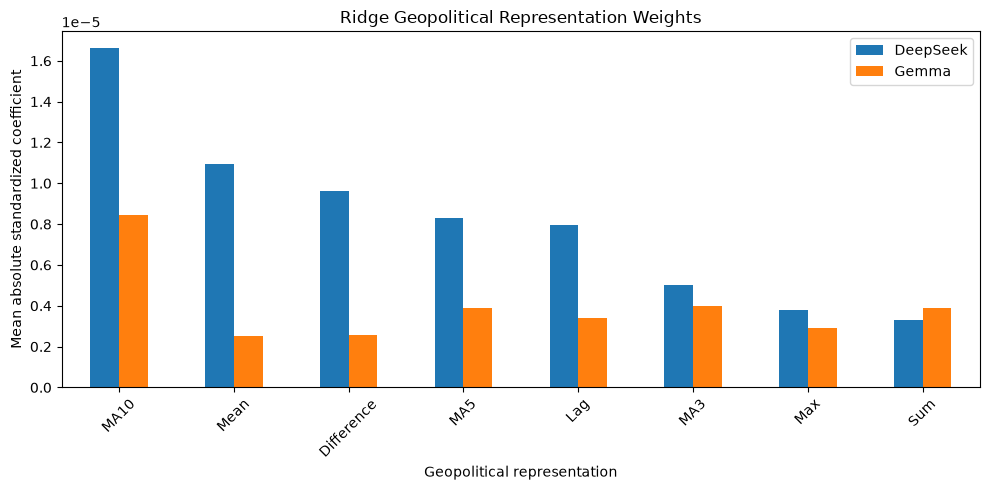

In [31]:
# Plot geopolitical representation weights

ridge_rep_plot = pd.DataFrame({
    "DeepSeek": representation_summary_deepseek["mean"],
    "Gemma": representation_summary_gemma["mean"]
}).fillna(0)

ridge_rep_plot = ridge_rep_plot.sort_values(
    "DeepSeek",
    ascending=False
)

ax = ridge_rep_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_xlabel("Geopolitical representation")
ax.set_ylabel("Mean absolute standardized coefficient")
ax.set_title(
    "Ridge Geopolitical Representation Weights"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ridge_geopolitical_representation_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Final Ridge summary

ridge_summary = pd.DataFrame({
    "model": [
        "DeepSeek_Ridge",
        "Gemma_Ridge"
    ],
    "best_alpha": [
        best_alpha_deepseek,
        best_alpha_gemma
    ],
    "validation_mse": [
        ridge_val_mse_deepseek[best_idx_deepseek],
        ridge_val_mse_gemma[best_idx_gemma]
    ],
    "test_rmse": [
        ridge_results.loc["DeepSeek_Ridge", "RMSE"],
        ridge_results.loc["Gemma_Ridge", "RMSE"]
    ],
    "test_mae": [
        ridge_results.loc["DeepSeek_Ridge", "MAE"],
        ridge_results.loc["Gemma_Ridge", "MAE"]
    ],
    "test_r2": [
        ridge_results.loc["DeepSeek_Ridge", "R2"],
        ridge_results.loc["Gemma_Ridge", "R2"]
    ],
    "top_geopolitical_representation": [
        representation_summary_deepseek.index[0],
        representation_summary_gemma.index[0]
    ]
})

display(ridge_summary)

,model,best_alpha,validation_mse,test_rmse,test_mae,test_r2,top_geopolitical_representation
0,DeepSeek_Ridge,6098.666701,0.000015,0.004474,0.003468,-0.116498,MA10
1,Gemma_Ridge,17990.099156,0.000015,0.004362,0.003408,-0.061175,MA10


In [33]:
# Save Ridge outputs

validation_summary.to_csv(
    OUTPUT_DIR / "ridge_validation_summary.csv",
    index=False
)

ridge_results.to_csv(
    OUTPUT_DIR / "ridge_test_metrics.csv"
)

ridge_summary.to_csv(
    OUTPUT_DIR / "ridge_summary.csv",
    index=False
)

ridge_coef_deepseek.to_csv(
    OUTPUT_DIR / "ridge_coefficients_deepseek.csv",
    index=False
)

ridge_coef_gemma.to_csv(
    OUTPUT_DIR / "ridge_coefficients_gemma.csv",
    index=False
)

representation_summary_deepseek.to_csv(
    OUTPUT_DIR / "ridge_geopolitical_representation_summary_deepseek.csv"
)

representation_summary_gemma.to_csv(
    OUTPUT_DIR / "ridge_geopolitical_representation_summary_gemma.csv"
)

index_rep_deepseek.to_csv(
    OUTPUT_DIR / "ridge_representation_by_index_deepseek.csv"
)

index_rep_gemma.to_csv(
    OUTPUT_DIR / "ridge_representation_by_index_gemma.csv"
)

ma10_deepseek.to_csv(
    OUTPUT_DIR / "ridge_ma10_features_deepseek.csv",
    index=False
)

ma10_gemma.to_csv(
    OUTPUT_DIR / "ridge_ma10_features_gemma.csv",
    index=False
)

print("Ridge outputs saved to:")
print(OUTPUT_DIR.resolve())

Ridge outputs saved to:
C:\Users\franc\OneDrive\Geop-Model\outputs\ridge_candidate_features


In [34]:
print("=" * 55)
print("RIDGE CANDIDATE-FEATURE ANALYSIS COMPLETE")
print("=" * 55)

print(f"Candidate predictors: {len(FEATURE_COLS)}")

print("\nDeepSeek")
print(f"Best alpha: {best_alpha_deepseek:.4f}")
print(
    "Top geopolitical representation:",
    representation_summary_deepseek.index[0]
)
print(
    "Test RMSE:",
    ridge_results.loc["DeepSeek_Ridge", "RMSE"]
)

print("\nGemma")
print(f"Best alpha: {best_alpha_gemma:.4f}")
print(
    "Top geopolitical representation:",
    representation_summary_gemma.index[0]
)
print(
    "Test RMSE:",
    ridge_results.loc["Gemma_Ridge", "RMSE"]
)

print("\nBenchmarks")
print(
    "Mean benchmark RMSE:",
    ridge_results.loc["Mean_Benchmark", "RMSE"]
)
print(
    "Zero benchmark RMSE:",
    ridge_results.loc["Zero_Benchmark", "RMSE"]
)

print("\nOutputs:")
print(OUTPUT_DIR.resolve())

RIDGE CANDIDATE-FEATURE ANALYSIS COMPLETE
Candidate predictors: 124

DeepSeek
Best alpha: 6098.6667
Top geopolitical representation: MA10
Test RMSE: 0.0044741380405025

Gemma
Best alpha: 17990.0992
Top geopolitical representation: MA10
Test RMSE: 0.004361883833064401

Benchmarks
Mean benchmark RMSE: 0.0042861051043039415
Zero benchmark RMSE: 0.004286889580202056

Outputs:
C:\Users\franc\OneDrive\Geop-Model\outputs\ridge_candidate_features
